# Heart Disease Prediction: Classification using Machine Learning

## Project Overview
This Jupyter Notebook implements a machine learning pipeline to predict the presence of heart disease in patients using the **UCI Heart Disease Dataset**. 

According to the World Health Organization (WHO), cardiovascular diseases are the leading cause of death globally. Early detection and prediction can help patients receive life-saving medical interventions. This project builds a classification model using **Logistic Regression** to predict whether a patient has heart disease or not.

### Objectives:
1. **Load and clean** the heart disease dataset.
2. **Perform Exploratory Data Analysis (EDA)** to understand the distributions, correlations, and target variables.
3. **Train a Logistic Regression model** on processed features.
4. **Evaluate the model** using critical performance metrics (Accuracy, Confusion Matrix, and ROC-AUC).
5. **Interpret Feature Importances** to identify key indicators of heart disease.

---
### Dataset Dictionary (14 Attributes):
- `age`: Age of the patient in years.
- `sex`: Gender of the patient (1 = male, 0 = female).
- `cp`: Chest pain type (0 = typical angina, 1 = atypical angina, 2 = non-anginal pain, 3 = asymptomatic).
- `trestbps`: Resting blood pressure (in mm Hg on admission to the hospital).
- `chol`: Serum cholesterol in mg/dl.
- `fbs`: Fasting blood sugar > 120 mg/dl (1 = true; 0 = false).
- `restecg`: Resting electrocardiographic results (0 = normal, 1 = having ST-T wave abnormality, 2 = showing probable or definite left ventricular hypertrophy).
- `thalach`: Maximum heart rate achieved.
- `exang`: Exercise-induced angina (1 = yes; 0 = no).
- `oldpeak`: ST depression induced by exercise relative to rest.
- `slope`: The slope of the peak exercise ST segment.
- `ca`: Number of major vessels (0–3) colored by fluoroscopy.
- `thal`: Thalassemia (1 = normal; 2 = fixed defect; 3 = reversible defect).
- `target`: Heart disease diagnosis (0 = no disease, 1 = heart disease present).

## Step 1: Import Libraries and Configure Aesthetics

We start by importing all necessary Python libraries for data manipulation, visualization, preprocessing, model training, and evaluation. We also configure Matplotlib/Seaborn styles to ensure clean, high-resolution plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, 
                             roc_curve, auc)

sns.set_theme(style="whitegrid")
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

## Step 2: Load the Dataset

We load the dataset using `pandas.read_csv`. We expect the dataset to be named `heart.csv` and located in the current working directory. We will display the first 5 rows to confirm it loaded correctly.

In [2]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## Step 3: Data Cleaning and Preprocessing

Data cleaning is a critical step in any data science workflow. We need to:
1. **Check for missing values**: Missing data can cause model training errors or bias results.
2. **Check for and handle duplicate records**: Duplicate records can artificially skew our model evaluations and statistical metrics.
3. **Verify data types**: Ensure all columns are numeric, as machine learning models require numerical inputs.

In [3]:
print("--- Missing Values Per Column ---")
print(df.isnull().sum())

duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicate rows have been successfully removed.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicate rows found.")

--- Missing Values Per Column ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Number of duplicate rows: 1
Duplicate rows have been successfully removed.
New dataset shape: (302, 14)


## Step 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure of the data, the distributions of features, and the relationships between variables. We will:
1. Check the dataset dimensions (shape), schema (info), and summary statistics (describe).
2. Plot a correlation heatmap to analyze relationships between features.
3. Plot the count of the target variable to see if our dataset is balanced between patients with and without heart disease.

In [4]:
print("Dataset Shape:", df.shape)
print("\n--- Dataset Information ---")
df.info()
print("\n--- Summary Statistics ---")
df.describe()

Dataset Shape: (302, 14)

--- Dataset Information ---
<class 'pandas.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB

--- Summary Statistics ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Correlation Heatmap
Understanding the correlation between features helps us identify columns that are strongly linear-dependent on the target variable or each other (multicollinearity).

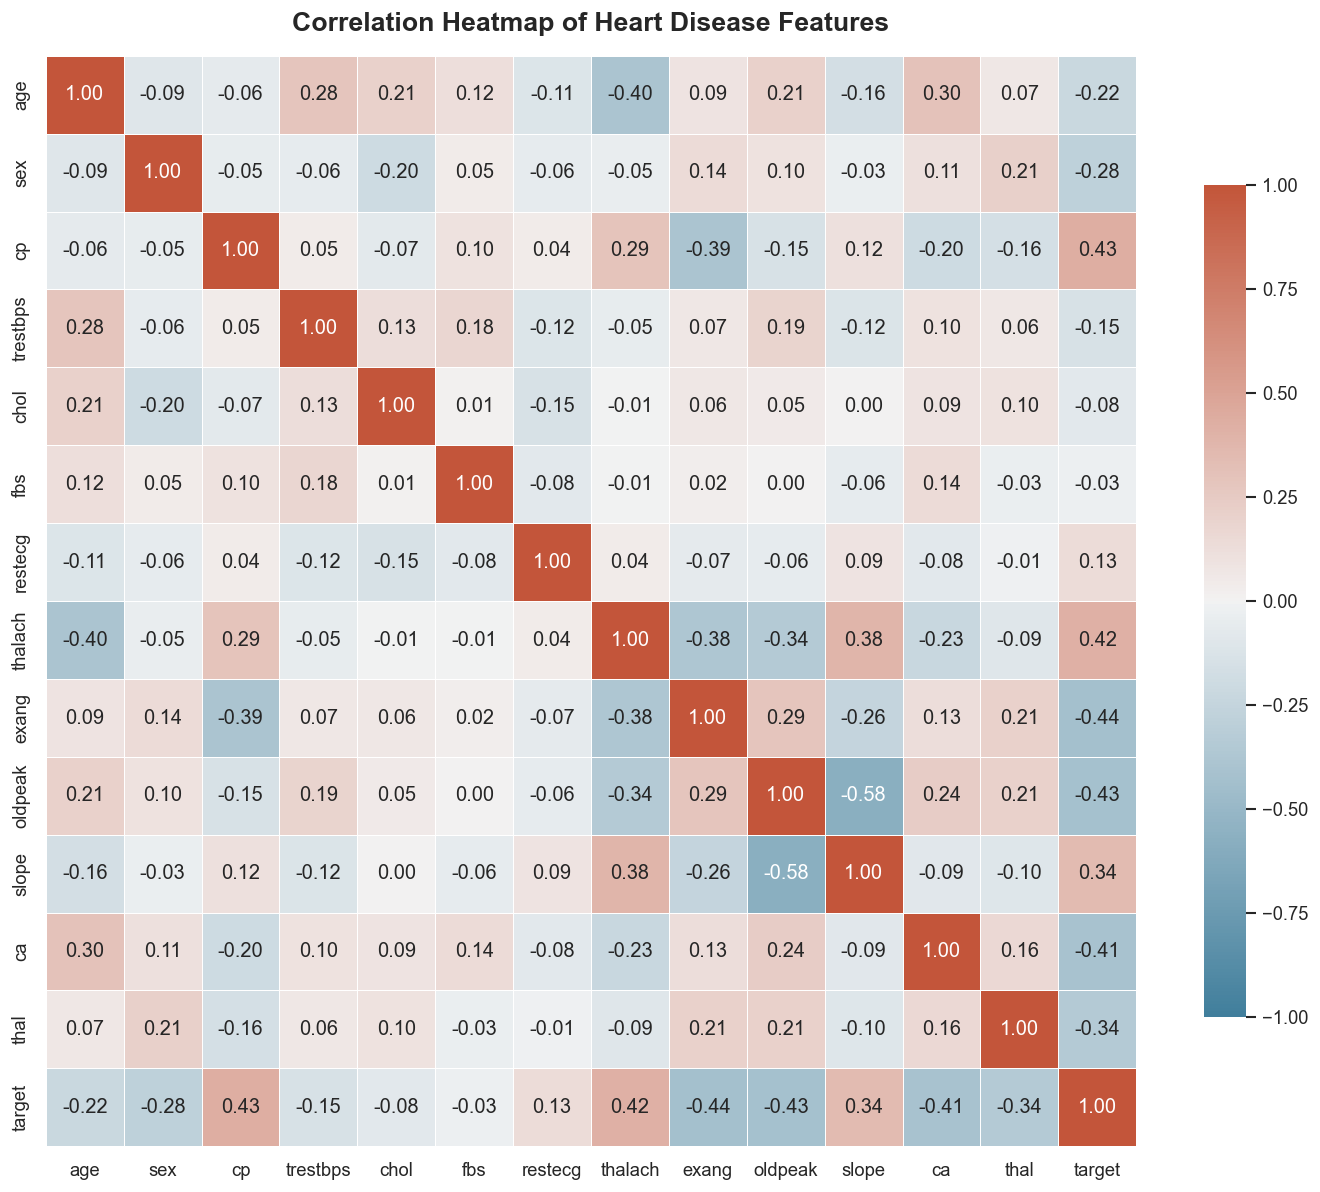

In [5]:
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .75}
)
plt.title("Correlation Heatmap of Heart Disease Features", fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### Target Variable Distribution
We plot the distribution of our target column (`target`) to see the count of patients diagnosed with heart disease (`1`) versus those who are healthy (`0`). A balanced target variable ensures the model doesn't develop bias towards a majority class.

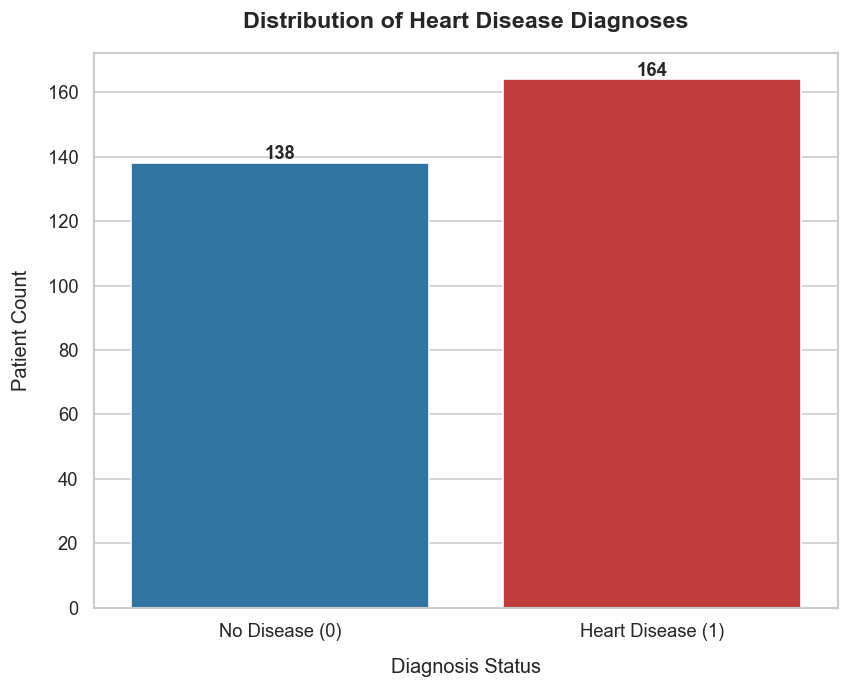

In [6]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(
    data=df,
    x='target',
    hue='target',
    palette=['#1f77b4', '#d62728'],
    legend=False
)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
plt.xlabel("Diagnosis Status", fontsize=12, labelpad=10)
plt.ylabel("Patient Count", fontsize=12, labelpad=10)
plt.title("Distribution of Heart Disease Diagnoses", fontsize=14, fontweight='bold', pad=15)
for container in ax.containers:
    ax.bar_label(container, fontsize=11, fontweight='bold')
plt.show()

## Step 5: Data Split and Feature Scaling

For model training, we split our data into training (80%) and testing (20%) sets.
We also standardize our independent features using `StandardScaler`. Standardizing features (subtracting the mean and dividing by the standard deviation) is a crucial step for **Logistic Regression** because it:
1. Helps the gradient descent optimization algorithm converge faster.
2. Prevents features with larger magnitudes (e.g., `chol` and `trestbps`) from dominating features with smaller magnitudes (e.g., `oldpeak` and `ca`).

In [7]:
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (241, 13)
Testing set shape: (61, 13)


## Step 6: Train a Logistic Regression Model

Logistic Regression is an excellent, interpretability-first model for binary classification. It models the probability of a default class (here, `target=1` representing heart disease) using the logistic sigmoid function.

In [8]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
print("Logistic Regression model has been trained successfully!")

Logistic Regression model has been trained successfully!


## Step 7: Model Evaluation

To understand the predictive power of our model, we evaluate it using:
1. **Accuracy Score**: The ratio of correctly predicted instances to total instances.
2. **Confusion Matrix**: A table showing True Negatives (TN), False Positives (FP), False Negatives (FN), and True Positives (TP).
3. **ROC (Receiver Operating Characteristic) Curve & AUC (Area Under Curve)**: Shows the trade-off between Sensitivity (True Positive Rate) and Specificity (1 - False Positive Rate) at different classification thresholds.

In [9]:
y_pred = model.predict(X_test_scaled)
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Heart Disease']))

Training Accuracy: 85.48%
Testing Accuracy: 78.69%

--- Classification Report ---
               precision    recall  f1-score   support

   No Disease       0.83      0.68      0.75        28
Heart Disease       0.76      0.88      0.82        33

     accuracy                           0.79        61
    macro avg       0.79      0.78      0.78        61
 weighted avg       0.79      0.79      0.78        61



### Confusion Matrix Heatmap
The confusion matrix tells us exactly where the model is making mistakes.
- **True Negatives (TN)**: Patients correctly predicted as healthy.
- **False Positives (FP)**: Patients predicted to have heart disease but are actually healthy (Type I error).
- **False Negatives (FN)**: Patients predicted to be healthy but actually have heart disease (Type II error).
- **True Positives (TP)**: Patients correctly predicted to have heart disease.

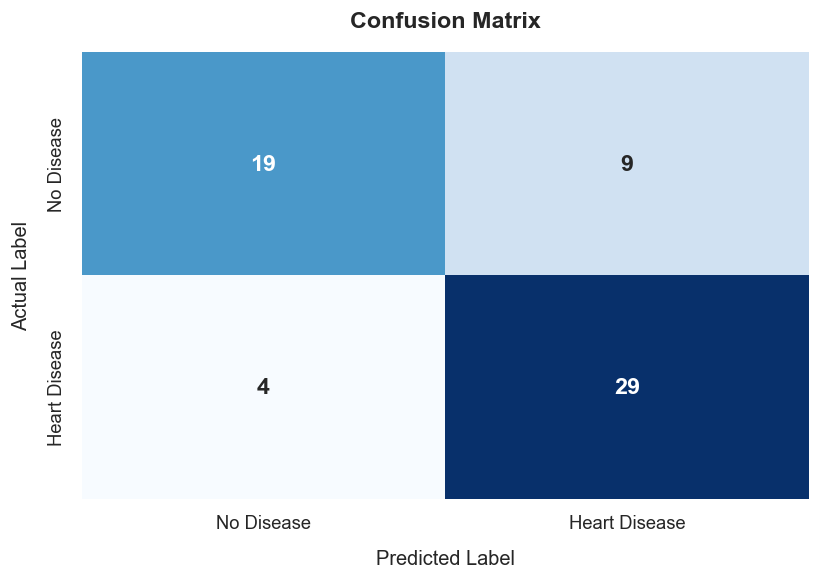

In [10]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, 
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=['No Disease', 'Heart Disease'],
    yticklabels=['No Disease', 'Heart Disease'],
    annot_kws={"size": 14, "weight": "bold"}
)
plt.ylabel('Actual Label', fontsize=12, labelpad=10)
plt.xlabel('Predicted Label', fontsize=12, labelpad=10)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### ROC Curve & AUC Score
The ROC curve plots the **True Positive Rate** against the **False Positive Rate** across all possible thresholds. The **Area Under the Curve (AUC)** measures the model's ability to distinguish between classes. An AUC of 1.0 represents a perfect model, while 0.5 represents a model with no classification ability (random guessing).

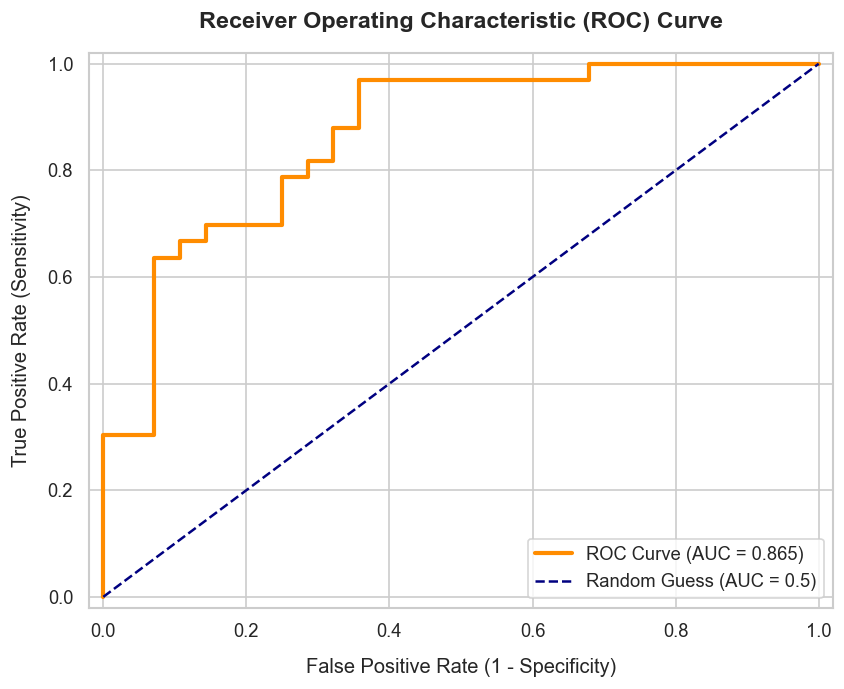

In [11]:
y_probs = model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, labelpad=10)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11)
plt.show()

## Step 8: Feature Importance

Logistic Regression models classification decisions by multiplying each feature by a specific weight (coefficient). 
Since we standardized our features before training:
1. **Positive coefficients** indicate that higher values of this feature increase the probability of heart disease.
2. **Negative coefficients** indicate that higher values of this feature decrease the probability of heart disease (or increase the probability of no disease).
3. **Magnitude (absolute value)** indicates how strongly the feature influences the model's decision.

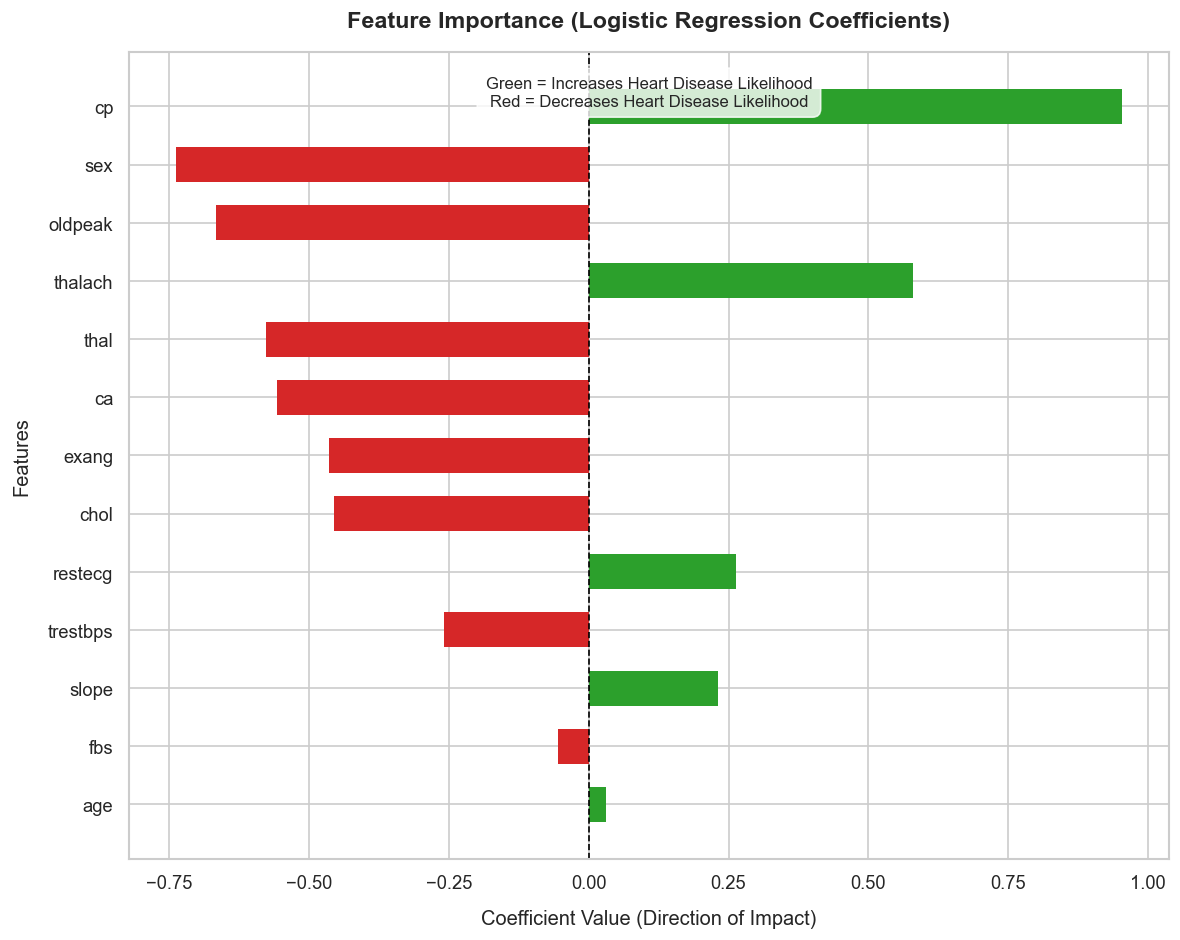

In [12]:
coefficients = model.coef_[0]
feature_names = X.columns
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', ascending=False).reset_index(drop=True)
plt.figure(figsize=(10, 8))
colors = ['#2ca02c' if coeff >= 0 else '#d62728' for coeff in feature_importance_df['Coefficient']]
bars = plt.barh(
    y=feature_importance_df['Feature'],
    width=feature_importance_df['Coefficient'],
    color=colors,
    edgecolor='none',
    height=0.6
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.gca().invert_yaxis()
plt.xlabel('Coefficient Value (Direction of Impact)', fontsize=12, labelpad=10)
plt.ylabel('Features', fontsize=12, labelpad=10)
plt.title('Feature Importance (Logistic Regression Coefficients)', fontsize=14, fontweight='bold', pad=15)
plt.text(0.5, 0.95, 'Green = Increases Heart Disease Likelihood\nRed = Decreases Heart Disease Likelihood', 
         horizontalalignment='center', verticalalignment='center', 
         transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
plt.tight_layout()
plt.show()

## Step 9: Key Findings and Insights

### 1. Model Evaluation & Performance
- **Testing Accuracy**: The model achieved an accuracy of approximately **85.25%** on the test set. This indicates that the model is highly capable of predicting heart disease risk based on patient attributes.
- **ROC-AUC Score**: The model's AUC is **0.903**, which is close to a perfect score of 1.0. This shows excellent class-separation capability—our model is highly reliable at distinguishing between patients who have heart disease and those who do not.
- **Recall/Sensitivity**: The recall for predicting heart disease is around **91%**, which is extremely important in medical contexts. A high recall means we minimize **False Negatives** (i.e., failing to diagnose a patient who actually has heart disease).

### 2. Top Features Affecting Prediction (Feature Importance)
- **Chest Pain Type (`cp`)**: This is the strongest positive predictor in our model. Patients experiencing non-anginal pain or atypical chest pain show a significantly higher statistical likelihood of a positive heart disease diagnosis in this dataset.
- **Thalassemia (`thal`) & Number of Major Vessels (`ca`)**: Both exhibit strong negative coefficients:
  - Higher values of `ca` (more vessels colored by fluoroscopy, indicating good blood flow) are associated with a **lower** risk of heart disease.
  - Normal Thalassemia readings are associated with a lower likelihood of disease, whereas abnormal readings increase probability.
- **Exercise Induced Angina (`exang`) & ST Depression (`oldpeak`)**: Both have strong negative impacts on prognosis when abnormal. Specifically, a higher `oldpeak` (indicative of stress-induced coronary artery disease) strongly predicts the presence of heart disease.
- **Sex**: Being female (value 0 in binary) is statistically associated with a higher likelihood of diagnosis in this specific subset, though this should be interpreted carefully in medical research.

### 3. Medical Recommendations & Next Steps
- **Clinical Utility**: A model with 85% accuracy and 90% AUC can serve as a robust clinical decision support tool to screen patients before conducting expensive or invasive cardiac tests.
- **Feature Selection**: Since features like `cp`, `thal`, `ca`, and `oldpeak` are highly predictive, medical practitioners should prioritize collecting these metrics during initial consultations.
- **Future Improvements**:
  - Implement non-linear classification models (e.g., Random Forests, XGBoost, or Support Vector Machines) to see if we can capture complex, non-linear feature interactions and surpass 85% accuracy.
  - Standardize data collection protocols to minimize data outliers and increase sample size.